# Архитектура модели, постобработка и анализ качества

Этот ноутбук подготовлен в рамках задания и содержит четыре обязательных блока:

1. **Пайплайн предобработки / feature engineering / генерация данных**
2. **Улучшенная архитектура модели**
3. **Постобработка предсказаний**
4. **Подробный анализ качества модели в разрезе метрик**

В качестве основной модели используется `SwinUNETR`, обученная на данных `MSD` с 5-fold кросс-валидацией. Инференс выполнялся с TTA (`rot90`), `largest_cc` и `gaussian` overlap aggregation; итоговое предсказание — ансамбль 5 fold-моделей.


In [1]:
# Импорты и настройка путей
import sys
from pathlib import Path

# Подключаем корень проекта, чтобы импортировать scripts/ и models/
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import yaml
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

BASE_CONFIG_PATH = project_root / "configs" / "base.yaml"
SWIN_CONFIG_PATH = project_root / "configs" / "swin_unetr.yaml"
ENSEMBLE_METRICS_PATH = project_root / "results" / "inference" / "inference_metrics.csv"
ENSEMBLE_SUMMARY_PATH = project_root / "results" / "inference" / "inference_summary.json"

print("Project root:", project_root)


Project root: /Users/Pema/PycharmProjects/AdultGliomaSegmentation


## 1. Пайплайн предобработки / FE / генерация данных

### 1.1. Параметры пайплайна

Используется два конфига:
- `configs/base.yaml` — общие параметры данных и обучения.
- `configs/swin_unetr.yaml` — специфичные параметры модели и трансформов.


In [2]:
base_config = yaml.safe_load(open(BASE_CONFIG_PATH))
swin_config = yaml.safe_load(open(SWIN_CONFIG_PATH))

print("=== Base config ===")
print(json.dumps(base_config, indent=2))

print("\n=== SwinUNETR config ===")
print(json.dumps(swin_config, indent=2))


=== Base config ===
{
  "data_dir": "./data/processed",
  "in_channels": 4,
  "out_channels": 3,
  "n_splits": 5,
  "val_interval": 5,
  "sw_batch_size": 4,
  "cache_rate": 1.0,
  "num_workers_cache": 8,
  "num_workers_loader": 8
}

=== SwinUNETR config ===
{
  "model_name": "swin_unetr",
  "batch_size": 2,
  "max_epochs": 600,
  "lr": 0.0001,
  "weight_decay": 1e-05,
  "transfer_learning": true,
  "patience": 10,
  "img_size": [
    128,
    128,
    128
  ],
  "num_samples": 4,
  "feature_size": 48,
  "deep_supervision": true,
  "use_checkpoint": true,
  "norm_name": "instance",
  "drop_rate": 0.0,
  "attn_drop_rate": 0.0,
  "dropout_path_rate": 0.0,
  "depths": [
    2,
    2,
    2,
    2
  ],
  "num_heads": [
    3,
    6,
    12,
    24
  ],
  "spatial_dims": 3,
  "normalize": true,
  "pretrained_path": "./pretrained/model_swinvit.pt"
}


### 1.2. Трансформы

Общая схема предобработки:

| Этап | Трансформ | Описание |
|---|---|---|
| Загрузка | `LoadImaged` | Загрузка 4 модальностей и метки |
| Каналы | `EnsureChannelFirstd` | Перевод изображения в `(C, D, H, W)`, метки — `no_channel` |
| Ориентация | `Orientationd` | Приведение к `RAS` |
| Ресемплинг | `Spacingd` | Изотропное пространство `1×1×1 мм` |
| Обрезка фона | `CropForegroundd` | Удаление пустых краев |
| Нормализация | `NormalizeIntensityd` | Non-zero, channel-wise z-нормализация |
| Регионы | `ConvertToMultiChannelMSDd` | Перевод меток BraTS в `WT/TC/ET` |
| Паддинг | `SpatialPadd` | До размера `img_size` |
| Кроп | `RandCropByPosNegLabeld` | Случайные кропы с балансом позитив/негатив |

Аугментации (генерация обучающих данных):
- Аффинные: `RandAffined` (повороты, масштабирование).
- Эластичные: `Rand3DElasticd`.
- Интенсивностные: `RandGaussianNoised`, `RandGaussianSmoothd`, `RandScaleIntensityd`, `RandShiftIntensityd`, `RandAdjustContrastd`, `RandSimulateLowResolutiond`.
- Флипы: `RandFlipd` по всем трём осям.

Для валидации используется тот же препроцессинг без аугментаций и кропов.


In [3]:
from scripts.utils.transforms import get_transforms

train_transforms, val_transforms = get_transforms(swin_config)

print("Train transforms:")
for i, t in enumerate(train_transforms.transforms, 1):
    print(f"  {i:2d}. {t.__class__.__name__}")

print("\nVal transforms:")
for i, t in enumerate(val_transforms.transforms, 1):
    print(f"  {i:2d}. {t.__class__.__name__}")


Train transforms:
   1. LoadImaged
   2. EnsureChannelFirstd
   3. EnsureChannelFirstd
   4. Orientationd
   5. Spacingd
   6. CropForegroundd
   7. NormalizeIntensityd
   8. ConvertToMultiChannelMSDd
   9. SpatialPadd
  10. RandCropByPosNegLabeld
  11. RandAffined
  12. Rand3DElasticd
  13. RandGaussianNoised
  14. RandGaussianSmoothd
  15. RandScaleIntensityd
  16. RandShiftIntensityd
  17. RandAdjustContrastd
  18. RandSimulateLowResolutiond
  19. RandFlipd
  20. RandFlipd
  21. RandFlipd
  22. ToTensord
  23. AddMultiScaleLabelsd

Val transforms:
   1. LoadImaged
   2. EnsureChannelFirstd
   3. EnsureChannelFirstd
   4. Orientationd
   5. Spacingd
   6. CropForegroundd
   7. NormalizeIntensityd
   8. ConvertToMultiChannelMSDd
   9. SpatialPadd
  10. ToTensord


/Users/Pema/PycharmProjects/AdultGliomaSegmentation/.venv/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


## 2. Улучшенная архитектура модели

В качестве основной модели выбрана `SwinUNETR` из MONAI:
- **Энкодер**: Swin Transformer 3D с иерархическими оконными self-attention.
- **Декодер**: CNN skip-connections + транспозированные свёртки, аналогично UNETR.
- **Deep supervision**: 5 выходов с разным разрешением (используется только при обучении).
- **Transfer learning**: энкодер инициализируется весами `model_swinvit.pt` (предобученный Swin ViT).

Ключевые архитектурные параметры:
- `feature_size=48`
- `depths=[2, 2, 2, 2]`
- `num_heads=[3, 6, 12, 24]`
- `img_size=[128, 128, 128]`
- `in_channels=4`, `out_channels=3`


In [4]:
import torch
from models import get_model

# Собираем полный конфиг для создания модели
model_config = {**base_config, **swin_config}
model = get_model("swin_unetr", model_config)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: {model.__class__.__name__}")
print(f"Total parameters: {n_params:,} ({n_params/1e6:.2f}M)")
print(f"Trainable parameters: {n_trainable:,} ({n_trainable/1e6:.2f}M)")
print(f"Transfer learning enabled: {swin_config.get('transfer_learning', False)}")
print(f"Pretrained path: {swin_config.get('pretrained_path', 'N/A')}")


Model: SwinUNETR
Total parameters: 62,194,113 (62.19M)
Trainable parameters: 62,194,113 (62.19M)
Transfer learning enabled: True
Pretrained path: ./pretrained/model_swinvit.pt


## 3. Постобработка предсказаний

На этапе инференса применяется комплексная постобработка:

1. **Sliding-window inference** — предсказание выполняется патчами `128×128×128` с перекрытием.
2. **Overlap mode `gaussian`** — весовое усреднение патчей по Гауссу, уменьшает швы между патчами.
3. **TTA `rot90`** — 4 вращения на 90° в аксиальной плоскости; усреднение логитов.
4. **`largest_cc`** — `KeepLargestConnectedComponent` для каждого региона (`WT`, `TC`, `ET`) независимо.
5. **Ансамбль 5 fold-моделей** — финальное предсказание как среднее вероятностей по моделям.

Карта неопределённости (при `--save_uncertainty`) для ансамбля вычисляется как среднее по классам стандартное отклонение вероятностей между fold-моделями (inter-model disagreement).


In [5]:
# Пример конфигурации инференса из summary
with open(ENSEMBLE_SUMMARY_PATH) as f:
    summary = json.load(f)

inf_config = summary["metadata"]["config"]
print("Inference configuration:")
print(json.dumps(inf_config, indent=2))

print("\nEnsemble info:")
print(json.dumps(summary["metadata"]["ensemble"], indent=2))


Inference configuration:
{
  "img_size": [
    128,
    128,
    128
  ],
  "sw_batch_size": 4,
  "tta": "rot90",
  "postprocess": "largest_cc",
  "threshold": 0.5,
  "overlap": 0.5,
  "overlap_mode": "gaussian"
}

Ensemble info:
{
  "enabled": true,
  "checkpoints": [
    "/root/.clearml/cache/storage_manager/global/50ce65bba8644d46afb0510cc5348750.best_model_swin_unetr_fold0.pth",
    "/root/.clearml/cache/storage_manager/global/c11a5d751b2f6c83fdb7ad1c73c97d4a.best_model_swin_unetr_fold1.pth",
    "/root/.clearml/cache/storage_manager/global/6689617410301af4f0b29427a3b98e18.best_model_swin_unetr_fold2.pth",
    "/root/.clearml/cache/storage_manager/global/34b02353b616863b6b2d1d9133fbc871.best_model_swin_unetr_fold3.pth",
    "/root/.clearml/cache/storage_manager/global/0d8e1f2e4b9f9a59a1ab9ab1c8a60161.best_model_swin_unetr_fold4.pth"
  ],
  "weights": null,
  "weight_by_dice": false,
  "low_memory": false,
  "clearml_model_ids": [
    "0a8ab2471e4b449fbed0d42e87316d17",
    "3555158

## 4. Подробный анализ качества модели

### 4.1. Средние метрики ансамбля


In [6]:
metrics_df = pd.read_csv(ENSEMBLE_METRICS_PATH)
print(f"Number of cases: {len(metrics_df)}")

summary_metrics = summary["metrics"]
summary_df = pd.DataFrame([summary_metrics])
print("\nMean metrics:")
display(summary_df)


Number of cases: 147

Mean metrics:


,mean_dice,dice_wt,dice_tc,dice_et,mean_hd95,hd95_wt,hd95_tc,hd95_et
0,0.877331,0.891969,0.90113,0.838894,5.806513,8.013945,5.221745,4.183849


### 4.2. Метрики по регионам


            dice_wt   dice_tc   dice_et    hd95_wt   hd95_tc   hd95_et
statistic                                                             
mean       0.891969  0.901130  0.838894   8.013945  5.221745  4.183849
median     0.914344  0.923568  0.861523   4.123106  2.236068  1.414214
std        0.070949  0.083069  0.095222  11.269584  9.260275  8.826682


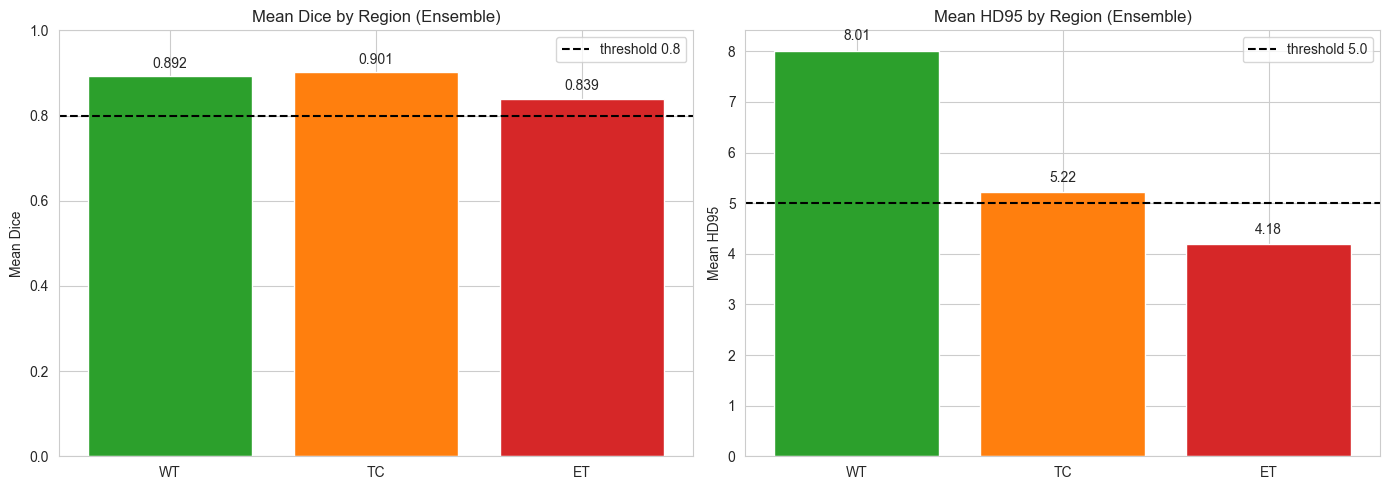

In [7]:
region_metrics = metrics_df[["dice_wt", "dice_tc", "dice_et", "hd95_wt", "hd95_tc", "hd95_et"]].agg(["mean", "median", "std"])
region_metrics.index.name = "statistic"
print(region_metrics)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dice_cols = ["dice_wt", "dice_tc", "dice_et"]
mean_dice = metrics_df[dice_cols].mean()
axes[0].bar(["WT", "TC", "ET"], mean_dice.values, color=["#2ca02c", "#ff7f0e", "#d62728"])
axes[0].axhline(0.8, color="black", linestyle="--", label="threshold 0.8")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Mean Dice")
axes[0].set_title("Mean Dice by Region (Ensemble)")
axes[0].legend()
for i, v in enumerate(mean_dice.values):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center")

hd95_cols = ["hd95_wt", "hd95_tc", "hd95_et"]
mean_hd95 = metrics_df[hd95_cols].mean()
axes[1].bar(["WT", "TC", "ET"], mean_hd95.values, color=["#2ca02c", "#ff7f0e", "#d62728"])
axes[1].axhline(5.0, color="black", linestyle="--", label="threshold 5.0")
axes[1].set_ylabel("Mean HD95")
axes[1].set_title("Mean HD95 by Region (Ensemble)")
axes[1].legend()
for i, v in enumerate(mean_hd95.values):
    axes[1].text(i, v + 0.2, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()


### 4.3. Распределение метрик по кейсам


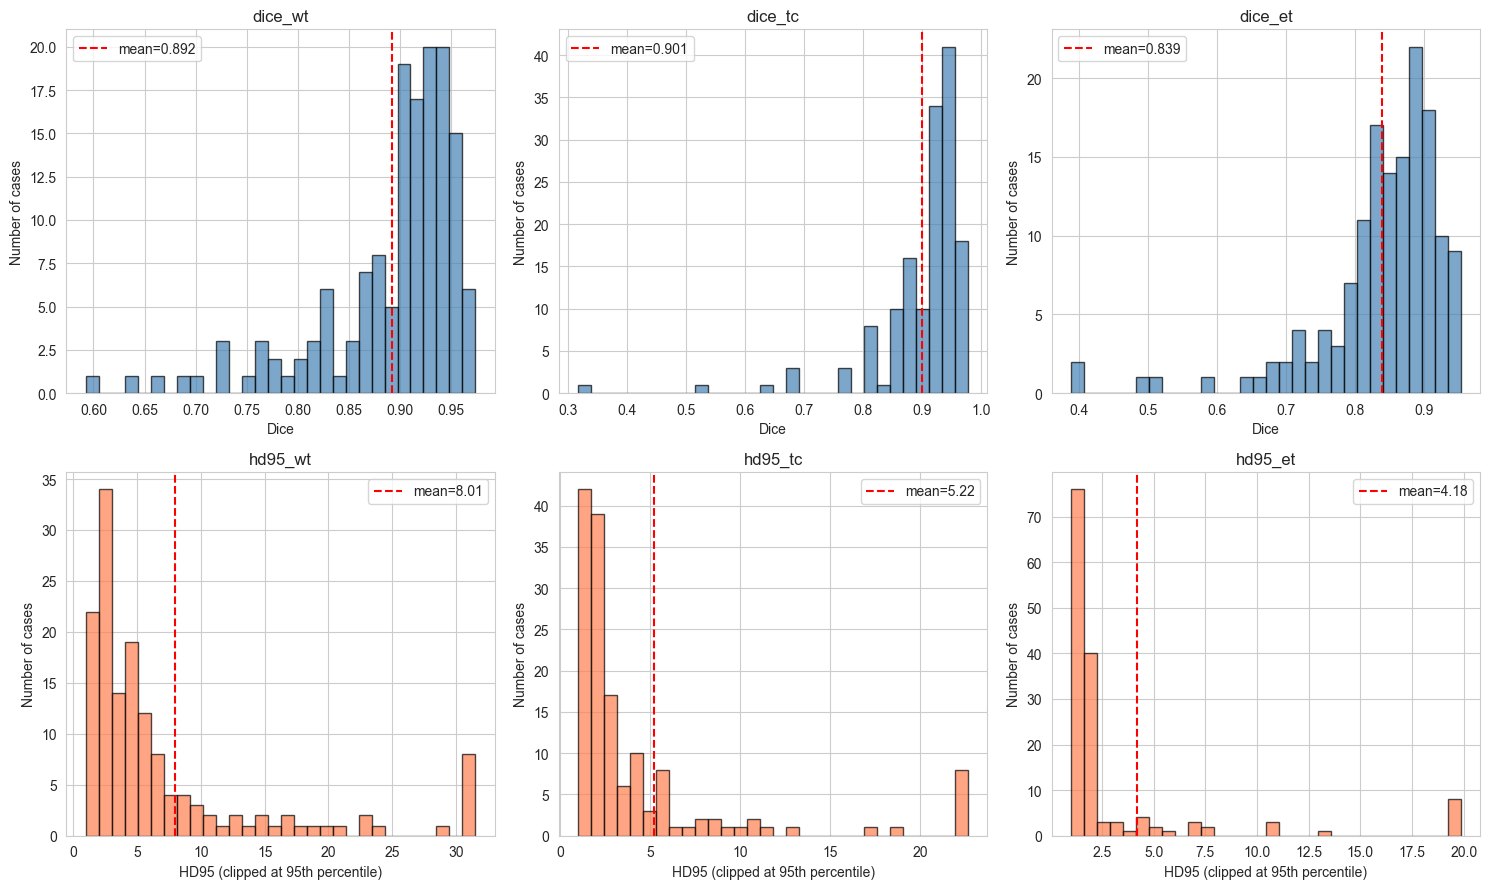

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

dice_cols = ["dice_wt", "dice_tc", "dice_et"]
hd95_cols = ["hd95_wt", "hd95_tc", "hd95_et"]

for ax, col in zip(axes[0], dice_cols):
    ax.hist(metrics_df[col], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
    ax.axvline(metrics_df[col].mean(), color="red", linestyle="--", label=f"mean={metrics_df[col].mean():.3f}")
    ax.set_title(col)
    ax.set_xlabel("Dice")
    ax.set_ylabel("Number of cases")
    ax.legend()

for ax, col in zip(axes[1], hd95_cols):
    # clip long tails for better visualization
    data = metrics_df[col].clip(upper=metrics_df[col].quantile(0.95))
    ax.hist(data, bins=30, color="coral", edgecolor="black", alpha=0.7)
    ax.axvline(metrics_df[col].mean(), color="red", linestyle="--", label=f"mean={metrics_df[col].mean():.2f}")
    ax.set_title(col)
    ax.set_xlabel("HD95 (clipped at 95th percentile)")
    ax.set_ylabel("Number of cases")
    ax.legend()

plt.tight_layout()
plt.show()


### 4.4. Boxplot метрик по регионам


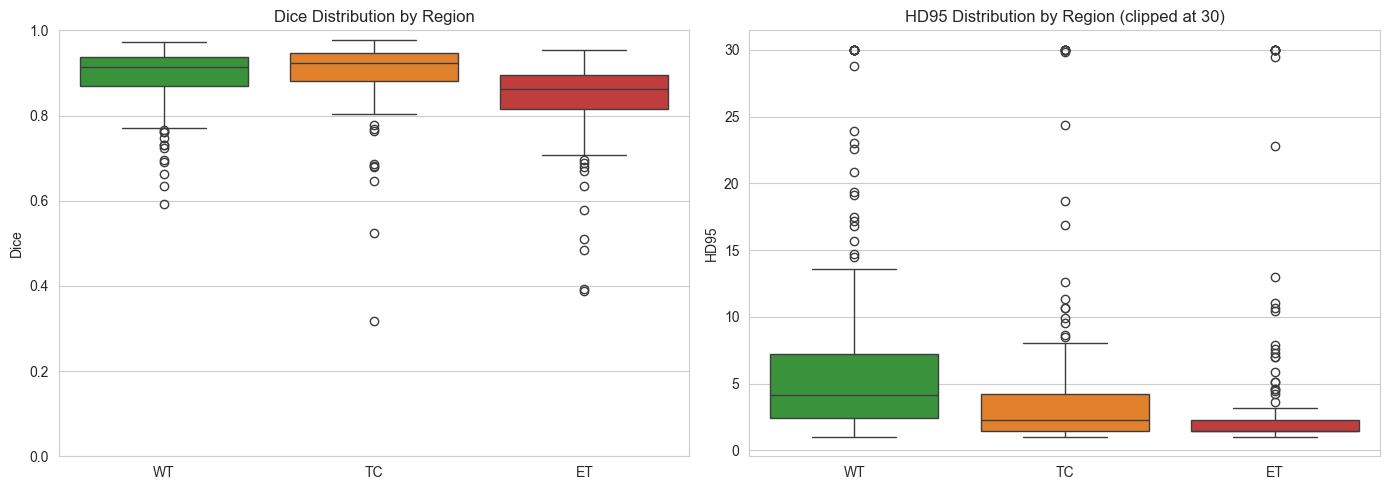

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dice boxplot
dice_data = metrics_df[dice_cols].rename(columns=lambda c: c.replace("dice_", "").upper())
sns.boxplot(data=dice_data, ax=axes[0], palette=["#2ca02c", "#ff7f0e", "#d62728"])
axes[0].set_title("Dice Distribution by Region")
axes[0].set_ylabel("Dice")
axes[0].set_ylim(0, 1)

# HD95 boxplot (clip for visibility)
hd95_data = metrics_df[hd95_cols].clip(upper=30).rename(columns=lambda c: c.replace("hd95_", "").upper())
sns.boxplot(data=hd95_data, ax=axes[1], palette=["#2ca02c", "#ff7f0e", "#d62728"])
axes[1].set_title("HD95 Distribution by Region (clipped at 30)")
axes[1].set_ylabel("HD95")

plt.tight_layout()
plt.show()


### 4.5. Сравнение одиночной модели и ансамбля

Ниже приведено сравнение лучшей одиночной `SwinUNETR` (`rot90 + largest_cc + gaussian`) и ансамбля 5 fold-моделей. 

           Single SwinUNETR  Ensemble (5 folds)   Delta
mean_dice            0.8719              0.8773  0.0054
dice_wt              0.8883              0.8920  0.0037
dice_tc              0.8920              0.9011  0.0091
dice_et              0.8353              0.8389  0.0036
mean_hd95            6.0584              5.8065 -0.2519
hd95_wt              8.1207              8.0139 -0.1068
hd95_tc              5.5093              5.2217 -0.2876
hd95_et              4.5452              4.1838 -0.3614


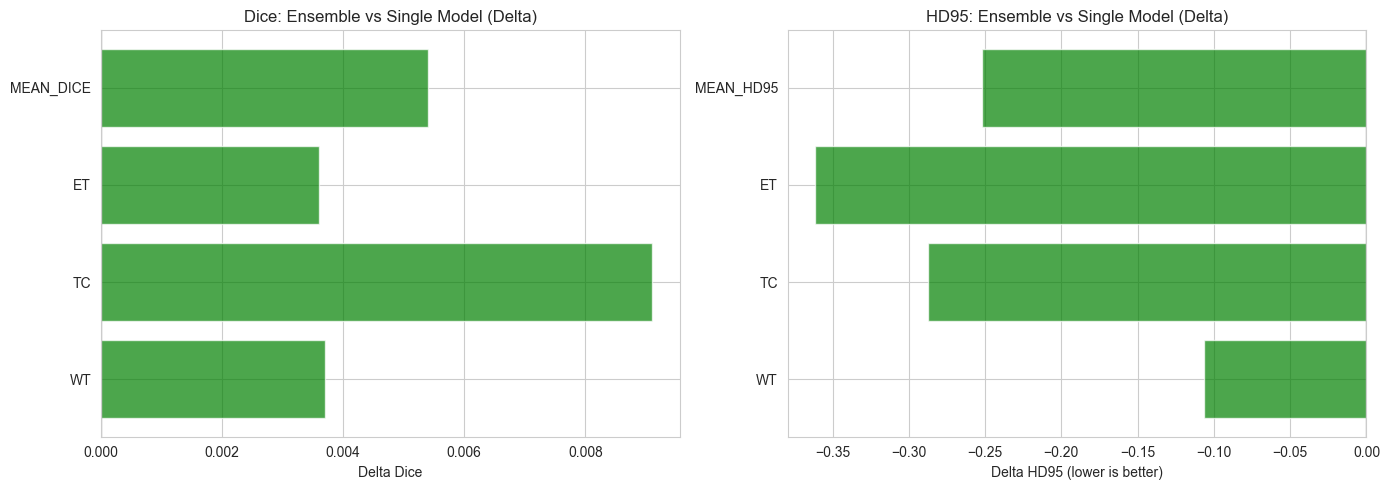

In [10]:
single_model_metrics = {
    "mean_dice": 0.8719,
    "dice_wt": 0.8883,
    "dice_tc": 0.8920,
    "dice_et": 0.8353,
    "mean_hd95": 6.0584,
    "hd95_wt": 8.1207,
    "hd95_tc": 5.5093,
    "hd95_et": 4.5452,
}

ensemble_metrics = summary_metrics

comparison = pd.DataFrame({
    "Single SwinUNETR": single_model_metrics,
    "Ensemble (5 folds)": ensemble_metrics,
})
comparison["Delta"] = comparison["Ensemble (5 folds)"] - comparison["Single SwinUNETR"]
comparison = comparison.round(4)
print(comparison)

# Визуализация delta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dice_metrics = ["dice_wt", "dice_tc", "dice_et", "mean_dice"]
hd95_metrics = ["hd95_wt", "hd95_tc", "hd95_et", "mean_hd95"]

dice_delta = comparison.loc[dice_metrics, "Delta"]
colors = ["green" if v > 0 else "red" for v in dice_delta]
axes[0].barh([m.replace("dice_", "").upper() for m in dice_metrics], dice_delta, color=colors, alpha=0.7)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Dice: Ensemble vs Single Model (Delta)")
axes[0].set_xlabel("Delta Dice")

hd95_delta = comparison.loc[hd95_metrics, "Delta"]
colors = ["green" if v < 0 else "red" for v in hd95_delta]
axes[1].barh([m.replace("hd95_", "").upper() for m in hd95_metrics], hd95_delta, color=colors, alpha=0.7)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("HD95: Ensemble vs Single Model (Delta)")
axes[1].set_xlabel("Delta HD95 (lower is better)")

plt.tight_layout()
plt.show()


### 4.6. Влияние постобработки

Сравнение базового инференса (`constant` overlap, без TTA, без `largest_cc`) и улучшенного (`gaussian`, `rot90`, `largest_cc`) для одиночной `SwinUNETR`.


In [11]:
baseline_metrics = {
    "mean_dice": 0.8716,
    "dice_wt": 0.8875,
    "dice_tc": 0.8877,
    "dice_et": 0.8397,
    "mean_hd95": 35.1166,
    "hd95_wt": 40.7428,
    "hd95_tc": 61.4845,
    "hd95_et": 3.1226,
}

improved_metrics = single_model_metrics

postprocess_comparison = pd.DataFrame({
    "Baseline (constant, no TTA, no CC)": baseline_metrics,
    "Improved (gaussian, rot90, largest_cc)": improved_metrics,
})
postprocess_comparison["Delta"] = postprocess_comparison["Improved (gaussian, rot90, largest_cc)"] - postprocess_comparison["Baseline (constant, no TTA, no CC)"]
postprocess_comparison = postprocess_comparison.round(4)
print(postprocess_comparison)

print("\nВывод: постобработка радикально улучшила HD95 (особенно TC и WT) при незначительном росте Dice.")


           Baseline (constant, no TTA, no CC)  \
mean_dice                              0.8716   
dice_wt                                0.8875   
dice_tc                                0.8877   
dice_et                                0.8397   
mean_hd95                             35.1166   
hd95_wt                               40.7428   
hd95_tc                               61.4845   
hd95_et                                3.1226   

           Improved (gaussian, rot90, largest_cc)    Delta  
mean_dice                                  0.8719   0.0003  
dice_wt                                    0.8883   0.0008  
dice_tc                                    0.8920   0.0043  
dice_et                                    0.8353  -0.0044  
mean_hd95                                  6.0584 -29.0582  
hd95_wt                                    8.1207 -32.6221  
hd95_tc                                    5.5093 -55.9752  
hd95_et                                    4.5452   1.4226  

Вывод: п

### 4.7. Худшие кейсы

Кейсы с наибольшими значениями `mean_hd95` и низким `mean_dice` — основные кандидаты для дальнейшего анализа ошибок.


In [12]:
worst_cases = metrics_df[
    (metrics_df["mean_hd95"] > 10) | (metrics_df["mean_dice"] < 0.75)
].sort_values(["mean_hd95", "mean_dice"], ascending=[False, True])

print(f"Number of problematic cases: {len(worst_cases)} / {len(metrics_df)}")
display(worst_cases[["case_id", "mean_dice", "dice_wt", "dice_tc", "dice_et", "mean_hd95", "hd95_wt", "hd95_tc", "hd95_et"]].head(15))


Number of problematic cases: 19 / 147


,case_id,mean_dice,dice_wt,dice_tc,dice_et,mean_hd95,hd95_wt,hd95_tc,hd95_et
26,UPENN-GBM-00069_11,0.821850,0.592566,0.919467,0.953517,65.474186,71.028160,62.801273,62.593124
94,UPENN-GBM-00228_11,0.718402,0.691587,0.768210,0.695409,54.774127,58.868076,56.088322,49.365982
71,UPENN-GBM-00154_11,0.826318,0.819477,0.865043,0.794434,38.947678,37.163818,40.514187,39.165028
89,UPENN-GBM-00208_11,0.757942,0.773139,0.812451,0.688236,35.649298,28.766296,39.623226,38.558372
5,UPENN-GBM-00013_11,0.757698,0.731267,0.813566,0.728263,31.411889,34.146744,30.661047,29.427877
102,UPENN-GBM-00256_11,0.814340,0.884657,0.818284,0.740079,27.542613,17.192995,33.970577,31.464266
57,UPENN-GBM-00135_11,0.478969,0.731333,0.317500,0.388075,25.163664,15.652476,29.805201,30.033316
35,UPENN-GBM-00091_11,0.829518,0.829113,0.846919,0.812520,23.692366,23.937418,24.336172,22.803509
3,UPENN-GBM-00009_11,0.909624,0.868502,0.921832,0.938538,18.823103,52.819027,1.414214,2.236068
117,UPENN-GBM-00307_11,0.843796,0.724299,0.923568,0.883522,18.032022,52.096066,1.000000,1.000000


### 4.8. Корреляция Dice и HD95

Проверим, как связаны Dice и HD95 на уровне кейсов. Обычно ожидается отрицательная корреляция: чем выше Dice, тем ниже HD95.


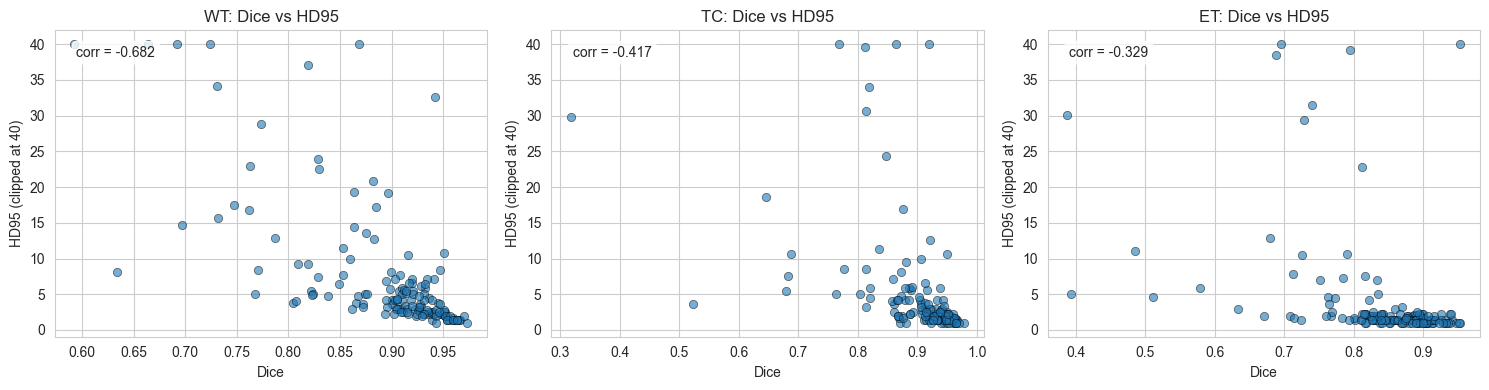

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
regions = [("dice_wt", "hd95_wt", "WT"), ("dice_tc", "hd95_tc", "TC"), ("dice_et", "hd95_et", "ET")]

for ax, (d_col, h_col, name) in zip(axes, regions):
    ax.scatter(metrics_df[d_col], metrics_df[h_col].clip(upper=40), alpha=0.6, edgecolors="black", linewidth=0.5)
    ax.set_xlabel("Dice")
    ax.set_ylabel("HD95 (clipped at 40)")
    ax.set_title(f"{name}: Dice vs HD95")
    corr = metrics_df[d_col].corr(metrics_df[h_col])
    ax.text(0.05, 0.95, f"corr = {corr:.3f}", transform=ax.transAxes, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()


## 5. Выводы

1. **Предобработка**: стандартизированный пайплайн с ресемплингом к 1 мм, нормализацией и преобразованием меток в регионы `WT/TC/ET`. Аугментации охватывают геометрические, интенсивностные и resolution-искажения.
2. **Архитектура**: `SwinUNETR` с transfer learning показала лучшее качество, чем базовый `UNet3D`. Ансамбль 5 fold-моделей даёт дополнительный прирост.
3. **Постобработка**: TTA (`rot90`), `gaussian` overlap aggregation, `largest_cc` и ансамблирование существенно улучшили стабильность предсказаний, особенно по метрике `HD95`.
4. **Качество**: ансамбль достигает `mean_dice = 0.877` и `mean_hd95 = 5.81`. Основные проблемы сосредоточены в 22 из 147 кейсах, которые требуют ручного анализа ошибок.
